In [2]:
import pandas as pd

In [1]:
a=3

In [3]:
import numpy as np
import os

# before: path = "../../data/processed/"
path = "data/processed"
dfs = {}

# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)
df1 = None
df2 = None
# keep the odds from the dataframe

# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# index SamplingOperations_code
# df = df.set_index('SamplingOperations_code')


# sort by Date_SamplingOperation
df = df.sort_values(by='Date_SamplingOperation')

# df = df[['CodeSite_SamplingOperations_x', 'Date_SamplingOperation', 'IBD', 'Longitude_Lambert93', 'Latitude_Lambert93']]
# DROP HERlvl2Code	Altitude Longitude_Lambert93	Latitude_Lambert93	Watershed	CodeDepartement	HERlvl1Code
# df = df.drop(columns=['HERlvl2Code', 'HERlvl2Name', 'HERlvl1Name', 'Altitude','Longitude_Lambert93','Latitude_Lambert93','Watershed','CodeDepartement', 'Date_SamplingOperation'])

In [4]:
# replace dateSamplingOperation for interger representing the date as YYYYMMDD
# convert to datetime first
df['Date_SamplingOperation'] = pd.to_datetime(df['Date_SamplingOperation'], format='%Y-%m-%d')
# then convert to integer YYYYMMDD
df['Date_SamplingOperation'] = df['Date_SamplingOperation'].dt.strftime('%Y%m%d').astype(int)

pd.set_option('display.max_columns', None)
df

SamplingOperations_code CodeSite_SamplingOperations_x  \
2703       S02115200_20070702                     S02115200   
33984      S05218450_20070709                     S05218450   
33929      S05217350_20070709                     S05217350   
48228      S05235850_20070709                     S05235850   
35408      S05234290_20070709                     S05234290   
...                       ...                           ...   
42720      S06580577_20230907                     S06580577   
35760      S06001284_20230907                     S06001284   
35783      S06001533_20230907                     S06001533   
38878      S06137040_20231011                     S06137040   
38873      S06137014_20231011                     S06137014   

       Date_SamplingOperation  TotalAbundance_SamplingOperation  Achaa01  \
2703                 20070702                               400      NaN   
33984                20070709                               400      NaN   
33929                20070709                               400      NaN   
48228                20070709                               400      NaN   
35408                20070709                               400      NaN   
...                       ...                               ...      ...   
42720                20230907                               426      NaN   
35760                20230907                               421      NaN   
35783                20230907                               401      NaN   
38878                20231011                               400      NaN   
38873                20231011                               405      NaN   

       Achac01  Achaf01  Achaf02  Achal01  Acham01  Achan01  Achat01  \
2703       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984      NaN     12.5      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      2.5      NaN      NaN      NaN      NaN      NaN   
35408      NaN      7.5      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...   
42720      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35760      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38878      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38873      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

         Achat02  Achat03  Achba01  Achbi01  Achbi02  Achbr01  Achca01  \
2703         NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984        NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929   5.000000      NaN      NaN      NaN      NaN      NaN      NaN   
48228  42.500000      NaN      NaN      NaN      NaN      NaN      NaN   
35408  20.000000      NaN      NaN      NaN      NaN      NaN      NaN   
...          ...      ...      ...      ...      ...      ...      ...   
42720   4.694836      NaN      NaN      NaN      NaN      NaN      NaN   
35760        NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783  14.962594      NaN      NaN      NaN      NaN      NaN      NaN   
38878  42.500000      NaN      NaN      NaN      NaN      NaN      NaN   
38873  69.135802      NaN      NaN      NaN      NaN      NaN      NaN   

       Achca02  Achca03  Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
2703       NaN      NaN      NaN      NaN      NaN      NaN     12.5      NaN   
33984      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35408      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...      ...   
42720      NaN 

In [21]:
# # drop Longitude_Lambert93	Latitude_Lambert93	Watershed	CodeDepartement	HERlvl1Code	HERlvl1Name	HERlvl2Code	HERlvl2Name	Altitude
# df = df.drop(columns=['Longitude_Lambert93','Latitude_Lambert93','Watershed','CodeDepartement','HERlvl1Code','HERlvl1Name','HERlvl2Code','HERlvl2Name','Altitude', 'IBD_EQR', 'IBD_EQR_Status'])

In [22]:
df

SamplingOperations_code CodeSite_SamplingOperations_x  \
2703       S02115200_20070702                     S02115200   
33984      S05218450_20070709                     S05218450   
33929      S05217350_20070709                     S05217350   
48228      S05235850_20070709                     S05235850   
35408      S05234290_20070709                     S05234290   
...                       ...                           ...   
42720      S06580577_20230907                     S06580577   
35760      S06001284_20230907                     S06001284   
35783      S06001533_20230907                     S06001533   
38878      S06137040_20231011                     S06137040   
38873      S06137014_20231011                     S06137014   

       Date_SamplingOperation  TotalAbundance_SamplingOperation  Achaa01  \
2703                 20070702                               400      NaN   
33984                20070709                               400      NaN   
33929                20070709                               400      NaN   
48228                20070709                               400      NaN   
35408                20070709                               400      NaN   
...                       ...                               ...      ...   
42720                20230907                               426      NaN   
35760                20230907                               421      NaN   
35783                20230907                               401      NaN   
38878                20231011                               400      NaN   
38873                20231011                               405      NaN   

       Achac01  Achaf01  Achaf02  Achal01  Acham01  Achan01  Achat01  \
2703       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984      NaN     12.5      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      2.5      NaN      NaN      NaN      NaN      NaN   
35408      NaN      7.5      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...   
42720      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35760      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38878      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38873      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

         Achat02  Achat03  Achba01  Achbi01  Achbi02  Achbr01  Achca01  \
2703         NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984        NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929   5.000000      NaN      NaN      NaN      NaN      NaN      NaN   
48228  42.500000      NaN      NaN      NaN      NaN      NaN      NaN   
35408  20.000000      NaN      NaN      NaN      NaN      NaN      NaN   
...          ...      ...      ...      ...      ...      ...      ...   
42720   4.694836      NaN      NaN      NaN      NaN      NaN      NaN   
35760        NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783  14.962594      NaN      NaN      NaN      NaN      NaN      NaN   
38878  42.500000      NaN      NaN      NaN      NaN      NaN      NaN   
38873  69.135802      NaN      NaN      NaN      NaN      NaN      NaN   

       Achca02  Achca03  Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
2703       NaN      NaN      NaN      NaN      NaN      NaN     12.5      NaN   
33984      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35408      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...      ...   
42720      NaN 

## No validation set

In [5]:
import numpy as np
import pandas as pd
from typing import Tuple, Optional
from catboost import CatBoostRegressor

def fit_catboost_and_fill(
    cleandf: pd.DataFrame,
    target: str = "IBD",
    base: Optional[dict] = None,         # e.g., {"loss_function":"RMSE","iterations":1500,"learning_rate":0.03,"depth":8}
    cat_params: Optional[dict] = None,
    use_ohe: bool = False                # False = native categoricals (recommended)
) -> Tuple[CatBoostRegressor, pd.DataFrame]:
    """
    Train on all rows with known target, then predict target for rows with NaN.
    Drops ['IBD','IBD_EQR','IBD_EQR_Status'] from features if present.
    Returns (fitted_model, scored_df) where scored_df = rows with NaN target + target_pred.
    """

    # 1) split into train/score by target presence
    df_train = cleandf[cleandf[target].notna()].copy()
    df_score = cleandf[cleandf[target].isna()].copy()

    # 2) drop leakage columns
    drop_cols = [c for c in ["IBD", "IBD_EQR", "IBD_EQR_Status"] if c in cleandf.columns]

    X = df_train.drop(columns=drop_cols + [target], errors="ignore")
    y = df_train[target].astype(float)

    # 3) detect dtypes
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    # 4) light preprocessing
    # numeric: leave NaN (CatBoost handles); categorical: fill with "(missing)"
    X_num = X[num_cols].copy()
    X_cat = X[cat_cols].copy().fillna("(missing)")

    if use_ohe:
        X_cat = pd.get_dummies(X_cat, drop_first=False)
        X_tr_proc = pd.concat([X_num.reset_index(drop=True),
                               X_cat.reset_index(drop=True)], axis=1)
        cat_features = None
    else:
        X_tr_proc = pd.concat([X_num.reset_index(drop=True),
                               X_cat.reset_index(drop=True)], axis=1)
        cat_features = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

    # 5) params and fit on ALL training data (no eval_set, no early stopping)
    base_params = base
    if cat_params:
        base_params.update(cat_params)

    model = CatBoostRegressor(**base_params)

    fit_kwargs = dict(X=X_tr_proc, y=y, use_best_model=False)
    if not use_ohe:
        fit_kwargs["cat_features"] = cat_features
    model.fit(**fit_kwargs)

    # 6) score NaN-target rows
    if df_score.empty:
        scored_df = pd.DataFrame(columns=list(cleandf.columns) + [f"{target}_pred"])
        return model, scored_df

    Xs = df_score.drop(columns=drop_cols + [target], errors="ignore")
    Xs_num = Xs[num_cols].copy()
    Xs_cat = Xs[cat_cols].copy().fillna("(missing)")

    if use_ohe:
        Xs_cat = pd.get_dummies(Xs_cat, drop_first=False)
        Xs_cat = Xs_cat.reindex(columns=X_cat.columns, fill_value=0)
        Xs_proc = pd.concat([Xs_num.reset_index(drop=True),
                             Xs_cat.reset_index(drop=True)], axis=1)
    else:
        Xs_proc = pd.concat([Xs_num.reset_index(drop=True),
                             Xs_cat.reset_index(drop=True)], axis=1)

    df_score[f"{target}_pred"] = model.predict(Xs_proc)
    scored_df = df_score

    return model, scored_df

# Validation set

In [24]:
# ===================== CatBoost (Regression) + FULL DIAGNOSTICS =====================
# pip install catboost scikit-learn matplotlib
# optional: pip install scipy shap

import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple, Dict, Any, Optional
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import style
style.mpl_apply()


try:
    from scipy import stats as _scipy_stats
except Exception:
    _scipy_stats = None

def _safe_ax(title: str, xlabel: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    return fig, ax

def _maybe_save(fig, outdir: Optional[Path], name: str, dpi: int = 140):
    if outdir:
        outdir.mkdir(parents=True, exist_ok=True)
        fig.savefig(outdir / f"{name}.png", bbox_inches="tight", dpi=dpi)

def _topn(series: pd.Series, k: int = 25) -> pd.Series:
    s = series.sort_values(ascending=False)
    return s.iloc[: min(k, len(s))]

def train_catboost_region_tunueado(
    cleandf: pd.DataFrame,
    target: str = "IBD",
    base: Optional[dict] = None,
    test_size: float = 0.10,
    random_state: int = 863,
    cat_params: Optional[dict] = None,
    use_ohe: bool = False,
    plots: bool = True,
    outdir: Optional[str] = None,
    perm_repeats: int = 10,
    perm_max_samples: int = 4000,
    shap_max_samples: int = 3000,
) -> Tuple["CatBoostRegressor", Dict[str, Any], pd.DataFrame, Dict[str, Any]]:
    """
    Train CatBoostRegressor with a validation split and produce exhaustive diagnostics.

    Returns:
        model: fitted CatBoostRegressor
        metrics: dict with train/valid metrics and overfitting gap
        scored_df: rows with missing target, with target_pred column if any
        artifacts: dict with evaluation results, feature importances, figures
                   keys: evals, figs, fi_split, fi_perm, preds_train, preds_valid
    """
    from catboost import CatBoostRegressor

    outdir_p = Path(outdir) if outdir else None

    # -----------------------------
    # 1) split train/score
    # -----------------------------
    df_train = cleandf[cleandf[target].notna()].copy()
    df_score = cleandf[cleandf[target].isna()].copy()

    drop_cols = [c for c in ["IBD", "IBD_EQR", "IBD_EQR_Status"] if c in cleandf.columns]

    X = df_train.drop(columns=drop_cols + [target], errors="ignore")
    y = df_train[target].astype(float)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # -----------------------------
    # 2) numeric / categorical
    # -----------------------------
    num_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_tr.select_dtypes(exclude=[np.number]).columns.tolist()

    # -----------------------------
    # 3) light imputations
    # -----------------------------
    # numeric: leave NaN (CatBoost handles); categorical: '(missing)'
    X_tr_num = X_tr[num_cols].copy()
    X_te_num = X_te[num_cols].copy()

    X_tr_cat = X_tr[cat_cols].copy().fillna("(missing)")
    X_te_cat = X_te[cat_cols].copy().fillna("(missing)")

    if use_ohe:
        X_tr_cat = pd.get_dummies(X_tr_cat, drop_first=False)
        X_te_cat = pd.get_dummies(X_te_cat, drop_first=False)
        X_tr_cat, X_te_cat = X_tr_cat.align(X_te_cat, join="left", axis=1, fill_value=0)
        X_tr_proc = pd.concat([X_tr_num.reset_index(drop=True),
                               X_tr_cat.reset_index(drop=True)], axis=1)
        X_te_proc = pd.concat([X_te_num.reset_index(drop=True),
                               X_te_cat.reset_index(drop=True)], axis=1)
        cat_features = None
        feature_names = list(X_tr_proc.columns)
    else:
        X_tr_proc = pd.concat([X_tr_num.reset_index(drop=True),
                               X_tr_cat.reset_index(drop=True)], axis=1)
        X_te_proc = pd.concat([X_te_num.reset_index(drop=True),
                               X_te_cat.reset_index(drop=True)], axis=1)
        cat_features = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
        feature_names = num_cols + cat_cols

    # -----------------------------
    # 4) parameters
    # -----------------------------
    base_defaults = dict(
        loss_function="RMSE",
        eval_metric="RMSE",
        iterations=5000,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3.0,
        random_seed=random_state,
        od_type="Iter",   # early stopping
        od_wait=200,
        bootstrap_type="Bayesian",
        bagging_temperature=0.2,
        verbose=200,
        allow_writing_files=False,
        grow_policy="Lossguide",
        min_data_in_leaf=16,
    )
    base_params = dict(base_defaults)
    if base:
        base_params.update(base)
    if cat_params:
        base_params.update(cat_params)

    model = CatBoostRegressor(**base_params)

    # -----------------------------
    # 5) fit with eval_set
    # -----------------------------
    fit_kwargs = dict(
        X=X_tr_proc, y=y_tr,
        eval_set=(X_te_proc, y_te),
        use_best_model=True,
    )
    if not use_ohe:
        fit_kwargs["cat_features"] = cat_features

    model.fit(**fit_kwargs)

    # -----------------------------
    # 6) metrics
    # -----------------------------
    pred_tr = model.predict(X_tr_proc)
    pred_te = model.predict(X_te_proc)

    def _rmse(y_true, y_hat):
        return float(np.sqrt(mean_squared_error(y_true, y_hat)))

    r2_tr = float(r2_score(y_tr, pred_tr))
    r2_te = float(r2_score(y_te, pred_te))
    rmse_tr = _rmse(y_tr, pred_tr)
    rmse_te = _rmse(y_te, pred_te)
    mae_tr = float(mean_absolute_error(y_tr, pred_tr))
    mae_te = float(mean_absolute_error(y_te, pred_te))

    best_iter = int(model.get_best_iteration() or model.tree_count_)
    metrics = {
        "R2_train": r2_tr,
        "R2_valid": r2_te,
        "MAE_train": mae_tr,
        "MAE_valid": mae_te,
        "RMSE_train": rmse_tr,
        "RMSE_valid": rmse_te,
        "best_iterations": best_iter,
        "gap_R2": float(r2_tr - r2_te),
        "gap_RMSE": float(rmse_te - rmse_tr),
        "used_ohe": bool(use_ohe),
        "n_train": int(len(y_tr)),
        "n_valid": int(len(y_te)),
        "n_features": int(len(feature_names)),
    }

    # -----------------------------
    # 7) score rows without target
    # -----------------------------
    if not df_score.empty:
        Xs = df_score.drop(columns=drop_cols + [target], errors="ignore")
        Xs_num = Xs[num_cols].copy()
        Xs_cat = Xs[cat_cols].copy().fillna("(missing)")
        if use_ohe:
            Xs_cat = pd.get_dummies(Xs_cat, drop_first=False)
            Xs_cat = Xs_cat.reindex(columns=X_tr_cat.columns, fill_value=0)
            Xs_proc = pd.concat([Xs_num.reset_index(drop=True),
                                 Xs_cat.reset_index(drop=True)], axis=1)
        else:
            Xs_proc = pd.concat([Xs_num.reset_index(drop=True),
                                 Xs_cat.reset_index(drop=True)], axis=1)
        df_score[target + "_pred"] = model.predict(Xs_proc)
        scored_df = df_score
    else:
        scored_df = pd.DataFrame(columns=list(cleandf.columns) + [target + "_pred"])

    # -----------------------------
    # 8) diagnostics: eval curves, residuals, importances, SHAP (optional)
    # -----------------------------
    artifacts: Dict[str, Any] = {}
    figs: Dict[str, Any] = {}

    # 8.1 learning curves
    evals = model.get_evals_result()
    artifacts["evals"] = evals
    if plots and evals and "learn" in evals and "validation" in evals:
        for metric_name in evals["learn"].keys():
            learn_vals = evals["learn"][metric_name]
            valid_vals = evals["validation"][metric_name]
            fig, ax = _safe_ax(f"Learning curve ({metric_name})",
                               "Iteration", metric_name)
            ax.plot(range(1, len(learn_vals) + 1), learn_vals, label="train")
            ax.plot(range(1, len(valid_vals) + 1), valid_vals, label="valid")
            ax.axvline(best_iter, ls="--", alpha=0.5, label="best_iter")
            ax.legend()
            _maybe_save(fig, outdir_p, f"curve_{metric_name}")
            figs[f"curve_{metric_name}"] = fig

    # 8.2 predicted vs actual (train/valid)
    if plots:
        # train
        fig, ax = _safe_ax("Predicted vs Actual (train)", "Actual", "Predicted")
        ax.scatter(y_tr, pred_tr, s=8, alpha=0.35)
        lo = np.nanmin([y_tr.min(), pred_tr.min()])
        hi = np.nanmax([y_tr.max(), pred_tr.max()])
        ax.plot([lo, hi], [lo, hi], ls="--")
        _maybe_save(fig, outdir_p, "pva_train")
        figs["pva_train"] = fig

        # valid
        fig, ax = _safe_ax("Predicted vs Actual (valid)", "Actual", "Predicted")
        ax.scatter(y_te, pred_te, s=10, alpha=0.45)
        lo = np.nanmin([y_te.min(), pred_te.min()])
        hi = np.nanmax([y_te.max(), pred_te.max()])
        ax.plot([lo, hi], [lo, hi], ls="--")
        _maybe_save(fig, outdir_p, "pva_valid")
        figs["pva_valid"] = fig

    # 8.3 residual plots
    res_tr = y_tr - pred_tr
    res_te = y_te - pred_te
    artifacts["preds_train"] = pd.DataFrame({"y": y_tr, "yhat": pred_tr, "resid": res_tr}).reset_index(drop=True)
    artifacts["preds_valid"] = pd.DataFrame({"y": y_te, "yhat": pred_te, "resid": res_te}).reset_index(drop=True)

    if plots:
        # histograms
        fig, ax = _safe_ax("Residuals histogram (train/valid)", "Residual", "Count")
        ax.hist(res_tr, bins=50, alpha=0.5, label="train")
        ax.hist(res_te, bins=50, alpha=0.5, label="valid")
        ax.legend()
        _maybe_save(fig, outdir_p, "residual_hist")
        figs["residual_hist"] = fig

        # residual vs fitted (valid)
        fig, ax = _safe_ax("Residuals vs Fitted (valid)", "Fitted", "Residual")
        ax.scatter(pred_te, res_te, s=10, alpha=0.45)
        ax.axhline(0.0, ls="--")
        _maybe_save(fig, outdir_p, "residual_vs_fitted_valid")
        figs["residual_vs_fitted_valid"] = fig

        # QQ plot (valid)
        if _scipy_stats is not None:
            fig = plt.figure(figsize=(5.0, 5.0))
            _scipy_stats.probplot(res_te, dist="norm", plot=plt)
            plt.title("QQ-plot of residuals (valid)")
            _maybe_save(fig, outdir_p, "qqplot_valid")
            figs["qqplot_valid"] = fig

    # 8.4 feature importance (split-based from CatBoost)
    try:
        fi_pretty = model.get_feature_importance(type="FeatureImportance",
                                                 prettified=True)
        fi_split = pd.DataFrame(fi_pretty)
        # ensure consistent column names
        if "Feature Id" in fi_split.columns and "Importance" in fi_split.columns:
            fi_split = fi_split.rename(columns={"Feature Id": "feature",
                                                "Importance": "importance"})
        elif set(["Feature Id", "Importances"]).issubset(fi_split.columns):
            fi_split = fi_split.rename(columns={"Feature Id": "feature",
                                                "Importances": "importance"})
        artifacts["fi_split"] = fi_split
        if plots and not fi_split.empty:
            top = _topn(fi_split.set_index("feature")["importance"], 30)
            fig, ax = _safe_ax("Feature importance (split-based, top 30)",
                               "Importance", "Feature")
            ax.barh(top.index[::-1], top.values[::-1])
            _maybe_save(fig, outdir_p, "fi_split_top30")
            figs["fi_split_top30"] = fig
    except Exception:
        artifacts["fi_split"] = pd.DataFrame(columns=["feature", "importance"])

    # # 8.5 permutation importance on validation
    # try:
    #     # subsample validation for speed if large
    #     if len(X_te_proc) > perm_max_samples:
    #         rng = np.random.default_rng(random_state)
    #         idx = rng.choice(len(X_te_proc), size=perm_max_samples, replace=False)
    #         X_perm = X_te_proc.iloc[idx].copy()
    #         y_perm = y_te.iloc[idx].copy()
    #     else:
    #         X_perm, y_perm = X_te_proc, y_te

    #     permi = permutation_importance(
    #         model, X_perm, y_perm,
    #         n_repeats=perm_repeats,
    #         random_state=random_state,
    #         scoring="neg_mean_squared_error",
    #         n_jobs=1
    #     )
    #     fi_perm = pd.DataFrame({
    #         "feature": feature_names,
    #         "importance": permi.importances_mean,
    #         "std": permi.importances_std
    #     }).sort_values("importance", ascending=False)
    #     artifacts["fi_perm"] = fi_perm

    #     if plots and not fi_perm.empty:
    #         top = fi_perm.head(30).iloc[::-1]
    #         fig, ax = _safe_ax("Permutation importance (valid, top 30)",
    #                            "Importance (↓MSE)", "Feature")
    #         ax.barh(top["feature"], top["importance"])
    #         _maybe_save(fig, outdir_p, "fi_perm_top30")
    #         figs["fi_perm_top30"] = fig
    # except Exception:
    #     artifacts["fi_perm"] = pd.DataFrame(columns=["feature", "importance", "std"])

    # 8.6 SHAP summary (optional)
    if plots:
        try:
            import shap
            # small sample for speed; use processed matrices to match model expectation
            if len(X_te_proc) > shap_max_samples:
                rng = np.random.default_rng(random_state)
                idx = rng.choice(len(X_te_proc), size=shap_max_samples, replace=False)
                X_shap = X_te_proc.iloc[idx]
            else:
                X_shap = X_te_proc

            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_shap)
            # summary plot
            fig = plt.figure(figsize=(7.0, 5.0))
            shap.summary_plot(shap_values, X_shap, show=False, max_display=25)
            plt.title("SHAP summary (valid sample)")
            _maybe_save(fig, outdir_p, "shap_summary")
            figs["shap_summary"] = fig
            artifacts["shap_sample_size"] = int(len(X_shap))
        except Exception:
            pass

    artifacts["figs"] = figs

    return model, metrics, scored_df, artifacts


# Training

In [6]:
from catboost.utils import get_gpu_device_count
print("GPUs visible to CatBoost:", get_gpu_device_count())

GPUs visible to CatBoost: 1


In [7]:
base_full2 = dict(
    task_type="GPU",
    devices="0",
    loss_function="RMSE", # or 
    iterations=10000,
    learning_rate=0.02,
    depth=8,
    l2_leaf_reg=7.0,
    random_strength=1.0,
    bagging_temperature=0.8,
    # rsm=0.8,                  # alias de colsample_bylevel en GPU
    grow_policy="Lossguide",  # mejor con muchas columnas
    min_data_in_leaf=32,
    max_bin=128,
    verbose=200,
    random_seed=42,
    od_type="Iter",
    od_wait=150,
    eval_metric="RMSE"
)

0:	learn: 2.7577386	test: 2.7372656	best: 2.7372656 (0)	total: 21.4ms	remaining: 3m 33s
200:	learn: 0.9629378	test: 0.9643152	best: 0.9643152 (200)	total: 3.51s	remaining: 2m 51s
400:	learn: 0.8053288	test: 0.8302476	best: 0.8302476 (400)	total: 6.12s	remaining: 2m 26s
600:	learn: 0.7309074	test: 0.7725291	best: 0.7725291 (600)	total: 8.44s	remaining: 2m 11s
800:	learn: 0.6770829	test: 0.7298174	best: 0.7298174 (800)	total: 10.7s	remaining: 2m 3s
1000:	learn: 0.6372129	test: 0.6982601	best: 0.6982601 (1000)	total: 12.8s	remaining: 1m 55s
1200:	learn: 0.6070527	test: 0.6746302	best: 0.6746302 (1200)	total: 14.9s	remaining: 1m 49s
1400:	learn: 0.5826235	test: 0.6565722	best: 0.6565722 (1400)	total: 16.9s	remaining: 1m 43s
1600:	learn: 0.5620095	test: 0.6414617	best: 0.6414617 (1600)	total: 18.8s	remaining: 1m 38s
1800:	learn: 0.5447706	test: 0.6287195	best: 0.6287195 (1800)	total: 20.8s	remaining: 1m 34s
2000:	learn: 0.5305424	test: 0.6181159	best: 0.6181159 (2000)	total: 22.7s	remaining

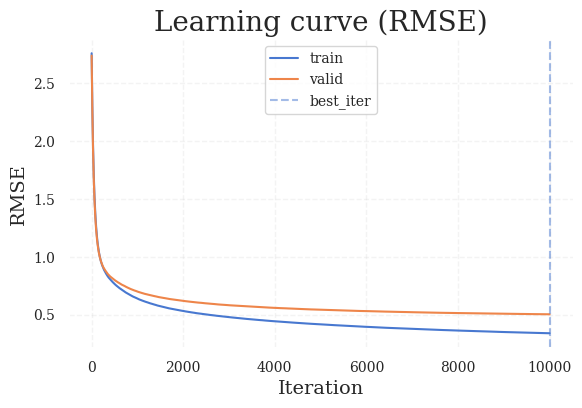

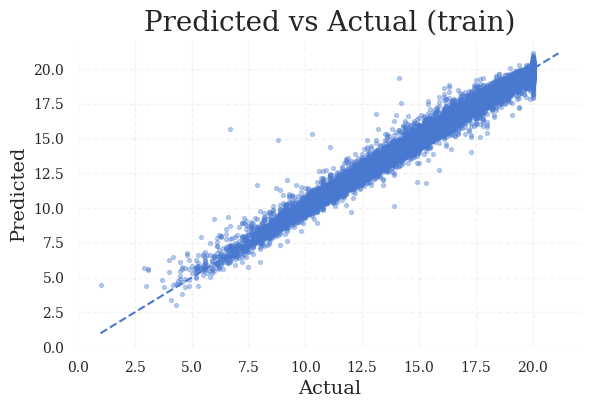

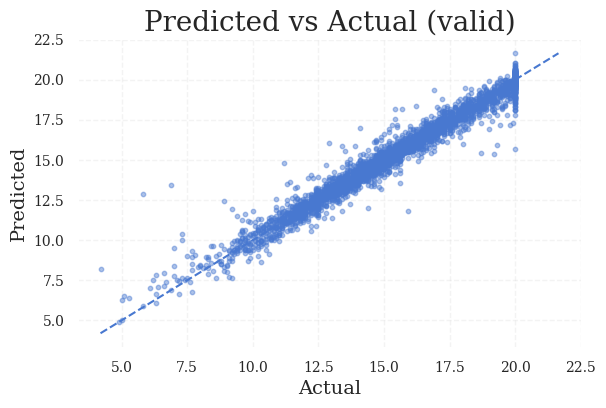

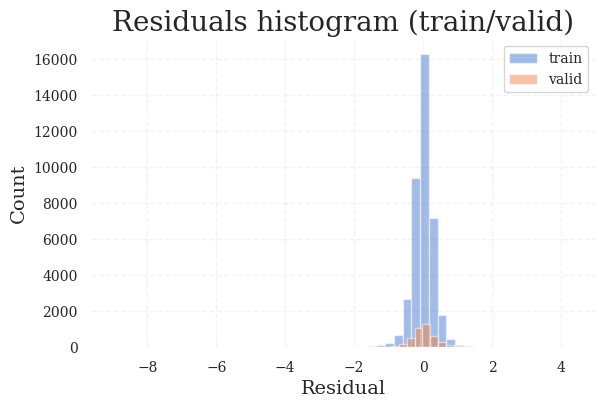

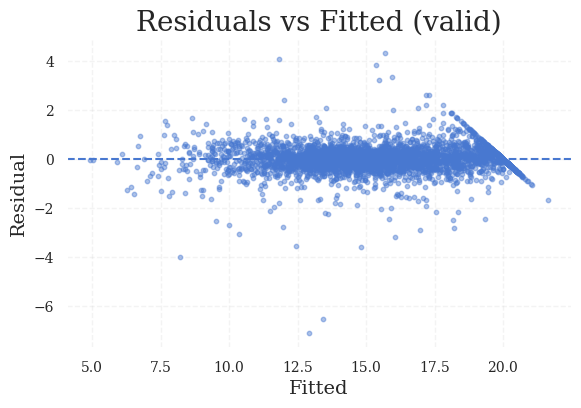

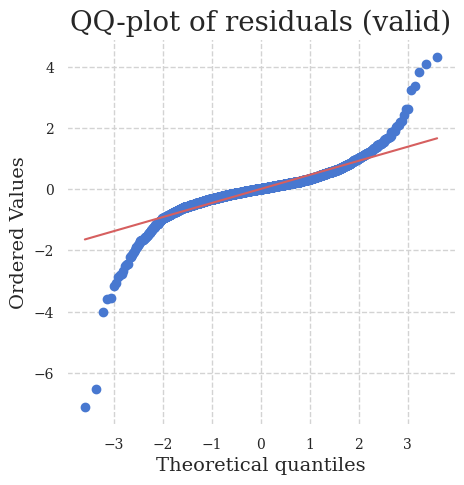

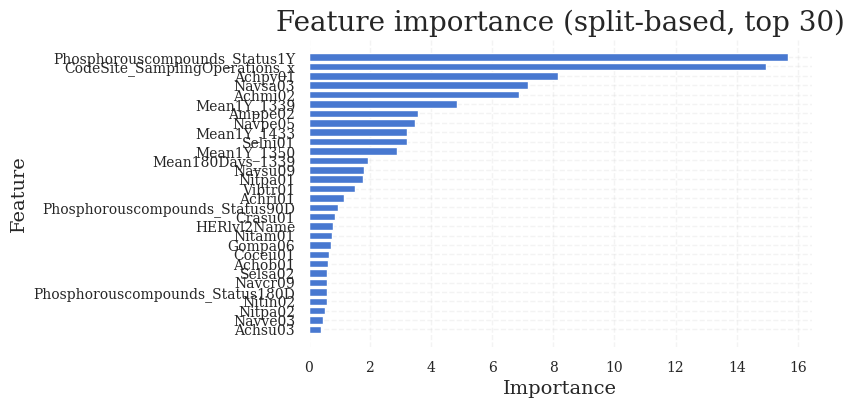

In [ ]:
model, scored_df, art = fit_catboost_and_fill(
    df,
    target="IBD",
    base=base_full2,
    test_size=0.1,
    random_state=863,
    use_ohe=False,
    plots=True,
    outdir="visualizations/Catboost_TPEPM",         # set to None to avoid saving
    perm_repeats=10,
    perm_max_samples=4000,
    shap_max_samples=2000,
)

In [28]:
print(metrics)
# Figures available in art["figs"], saved under ./cb_diagnostics/*.png if outdir provided
# Split-based importance: art["fi_split"]; Permutation importance: art["fi_perm"]

{'R2_train': 0.9864055278046535, 'R2_valid': 0.9672781597298796, 'MAE_train': 0.22096308214363017, 'MAE_valid': 0.3130821441801457, 'RMSE_train': 0.3258846172552568, 'RMSE_valid': 0.5019636728145326, 'best_iterations': 9999, 'gap_R2': 0.019127368074773887, 'gap_RMSE': 0.17607905555927578, 'used_ohe': False, 'n_train': 39211, 'n_valid': 4357, 'n_features': 2850}


In [29]:
scored_df = scored_df[['SamplingOperations_code','IBD_pred']]
# rename IBD_pred to IBD_EQR_Status
scored_df.rename(columns={'IBD_pred':'IBD_EQR_Status'}, inplace=True)

In [30]:
scored_df.to_csv('results/015_Catboost2/015_Catboost2_TPEPM.csv', index=False)

In [31]:
# save the model joblib
import joblib
joblib.dump(model, 'results/015_Catboost2/015_Catboost2_TPEPM.joblib', compress=3)

['results/015_Catboost2/015_Catboost2_TPEPM.joblib']